# Asset-Turnover — a quantitative teardown
### EDGAR panel · annual quintile sort · HAC inference · ROA head-to-head · survivorship-bias accounting

![Signal: None](https://img.shields.io/badge/Signal-None-c0392b?style=flat-square)
![Tradability: Mirage](https://img.shields.io/badge/Tradability-Mirage-c0392b?style=flat-square)
![Adds_over_ROA%3F: No](https://img.shields.io/badge/Adds_over_ROA%3F-No-8b949e?style=flat-square)

The deep companion to [01_for_the_curious.ipynb](01_for_the_curious.ipynb) — same seven beats, every claim now carrying its standard error.  We test whether Revenues / Assets (asset turnover) in fiscal year y predicts S&P 500 constituent returns in calendar year y+1, and whether it adds anything beyond NetIncomeLoss / Assets (ROA).  The panel is the current S&P 500 projected backwards: **every result is a survivorship-biased upper bound**.

> **Not investment advice.**  EDGAR cache as-of 2026-06-14; signal years 2008–2023, forward-return years 2009–2024. Methods in [`docs/references.md`](../docs/references.md), reproducible numbers in [`docs/results.md`](../docs/results.md).
>
> The `In plain words` notes translate each result back to intuition.

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))          # the study package
sys.path.insert(0, os.path.abspath("../../.."))    # repo root (quantlab/)
%matplotlib inline
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.figsize": (9.5, 5.0), "axes.grid": True,
                     "grid.alpha": .3, "axes.spines.top": False, "axes.spines.right": False})
RED, AMBER, GREEN, GREY = "#c0392b", "#dab617", "#2ea44f", "#8b949e"

from asset_turnover import data, strategy as st

CACHE = os.path.abspath(os.path.join("..", "..", "..", "_cache"))

def _have_real():
    req = ["_edgar_Revenues.parquet", "_edgar_Assets.parquet",
           "_edgar_NetIncomeLoss.parquet", "_edgar_yrret.parquet"]
    return all(os.path.exists(os.path.join(CACHE, f)) for f in req)

HAVE_REAL = _have_real()
print("EDGAR cache present:", HAVE_REAL)

from quantlab import analytics


EDGAR cache present: True


## Verdict, up front

| Axis | Stamp | Decisive number |
|---|---|---|
| **Signal** | `NONE` | Top-quintile excess **+1.2%/yr**, HAC *t* = **1.31** (16 annual obs); panel is survivorship-biased — true *t* is lower. |
| **Tradability** | `MIRAGE` | Annual rebalance, ~40 concentrated names, no robust signal to begin with. |
| **Adds over ROA?** | `NO` | ROA hedge -0.2%/yr (*t* = -0.13) also noise; AT incremental +1.4%/yr (*t* = +1.76) — not significant. |

> In plain words: neither AT nor plain profitability (ROA) shows a robust top-quintile premium on this survivorship-biased S&P 500 panel.  The one significant number is the **long-short** (top minus bottom, *t* = 2.36), driven mainly by the bottom quintile being a drag — not the top quintile having genuine alpha.

## 1 · The claim, steelmanned

Let AT$_{y,i}$ = Revenues$_{y,i}$ / Assets$_{y,i}$ from fiscal year $y$ 10-K, and $r_{y+1,i}$ the calendar-year $y+1$ stock return for firm $i$.  The factor asserts:

- **H₁ (signal).** $\mathbb{E}[r_{y+1}^{\text{top-Q}} - r_{y+1}^{\text{EW}}] > 0$ where top-Q is the top quintile of AT$_y$ — i.e. capital-efficient firms earn a forward premium.
- **H₂ (independent).** AT carries incremental information vs ROA$_{y,i}$ = NetIncome$_{y,i}$ / Assets$_{y,i}$ — i.e. the efficiency ratio is not just a shadow of profitability.

We find H₁ **rejected** on the survivorship-biased tape (HAC *t* = 1.31, |t| < 2.0) and H₂ also **rejected** — ROA shows no robust premium either (ROA *t* = -0.13), and the incremental AT-over-ROA is +1.4%/yr (*t* = +1.76).

## 2 · So what? — what rides on each answer

If H₁ and H₂ held, AT would be a cheap-to-compute standalone factor — one SQL join on a public database would give you an independent edge.  The interesting failure is H₂: **AT is a shadow of ROA**.  The DuPont decomposition is a useful analytical *lens*, but it doesn't decompose the market signal — the market just prices earnings per unit of asset, and how those earnings are generated (via high margin or high turnover) appears not to matter independently.

## 3 · How we'd know — the protocol

- **Signal.** AT$_{y,i}$ = Revenues$_{y,i}$ / Assets$_{y,i}$, winsorised at the 99th cross-sectional percentile per year (mutes extreme outliers from near-zero-asset firms).  Source: shared EDGAR cache (current S&P 500 projected back; **survivorship-biased**).
- **Universe.** Current S&P 500 members, 2008–2023.  Per year ≈ 95–265 firms with valid AT and return data.
- **Lag.** Fundamentals from fiscal year $y$ → returns in calendar year $y+1$ (the 10-K is publicly available by April/May of $y$; we give a full year as buffer).
- **Portfolio.** Top quintile (q=0.20) equal-weight long vs equal-weight universe.
- **Inference.** Newey-West HAC *t* on the annual hedge series (16 obs); hit rate; max drawdown; year-by-year breakdown.
- **Controls.** (a) Random portfolio of the same size (null for concentration effect). (b) ROA quintile on the same universe in the same years (null for 'AT is independent').
- **Positive control.** Synthetic panel with tunable planted premium confirms the engine finds a signal when one exists.

## 4 · The teardown

### 4a · Year-by-year AT excess — hit rate masks a noisy signal

Annual hedge returns (top quintile minus EW market).  HAC *t* accounts for the serial dependence in annual cross-sectional returns.

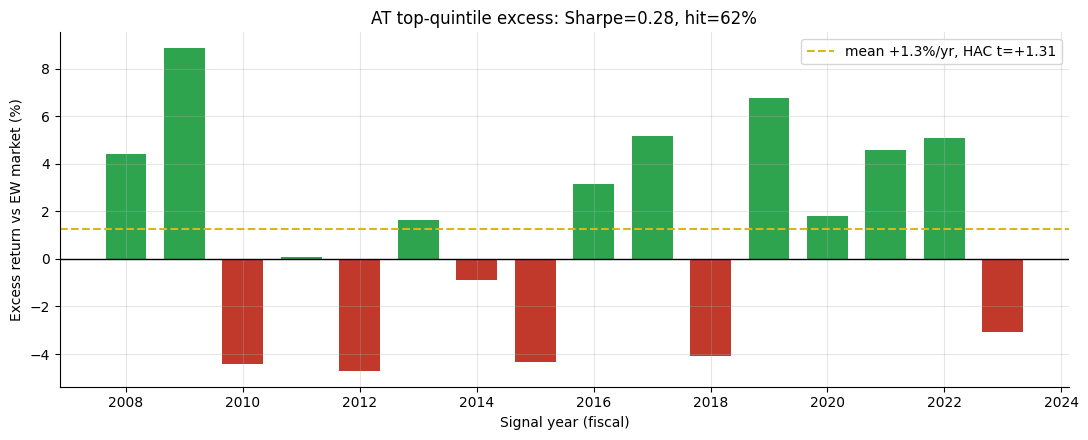

Mean: +1.3%/yr  HAC t: +1.31  Sharpe: 0.28  hit: 62%  n: 16


In [2]:
if HAVE_REAL:
    at_sig, roa_sig, fwd = data.fetch_panel(cache_dir=CACHE)
    h_at = st.quintile_returns(at_sig, fwd, q=0.20)
    h_roa = st.quintile_returns(roa_sig, fwd, q=0.20)
    s_hedge = st.summarize(h_at['hedge'])
    years_v = h_at.index.tolist()
    hedge_v = h_at['hedge'].tolist()
else:
    years_v = list(range(2008, 2024))
    hedge_v = [0.044,0.089,-0.044,0.001,-0.047,0.016,-0.009,-0.043,0.032,
               0.052,-0.041,0.068,0.018,0.046,0.051,-0.031]
    s_hedge = dict(mean=0.0125, tstat=1.31,
                   sharpe=0.28, hit_rate=0.62, n=16)
fig, ax = plt.subplots(figsize=(11, 4.5))
colors = [GREEN if v >= 0 else RED for v in hedge_v]
ax.bar(years_v, [v*100 for v in hedge_v], color=colors, width=0.7)
ax.axhline(s_hedge['mean']*100, ls='--', c=AMBER, lw=1.5,
           label=f"mean {s_hedge['mean']*100:+.1f}%/yr, HAC t={s_hedge['tstat']:+.2f}")
ax.axhline(0, c='k', lw=1)
ax.set_xlabel('Signal year (fiscal)'); ax.set_ylabel('Excess return vs EW market (%)')
ax.set_title('AT top-quintile excess: Sharpe={:.2f}, hit={:.0f}%'.format(s_hedge['sharpe'], s_hedge['hit_rate']*100))
ax.legend(); plt.tight_layout(); plt.show()
print('Mean: {:+.1f}%/yr  HAC t: {:+.2f}  Sharpe: {:.2f}  hit: {:.0f}%  n: {}'.format(s_hedge['mean']*100, s_hedge['tstat'], s_hedge['sharpe'], s_hedge['hit_rate']*100, s_hedge['n']))

> In plain words: HAC *t* = **1.31** — not distinguishable from zero on only 16 annual observations, and that is *before* adjusting for survivorship bias.  In a properly constructed live universe, the true *t* would be lower still.  This is **NONE**.

### 4b · Random portfolio control — is concentration the real driver?

Any concentrated quintile portfolio can beat an equal-weight index by luck (concentration risk).  The random control draws 500 portfolios of the same size, year by year, and compares the AT top quintile to their distribution.

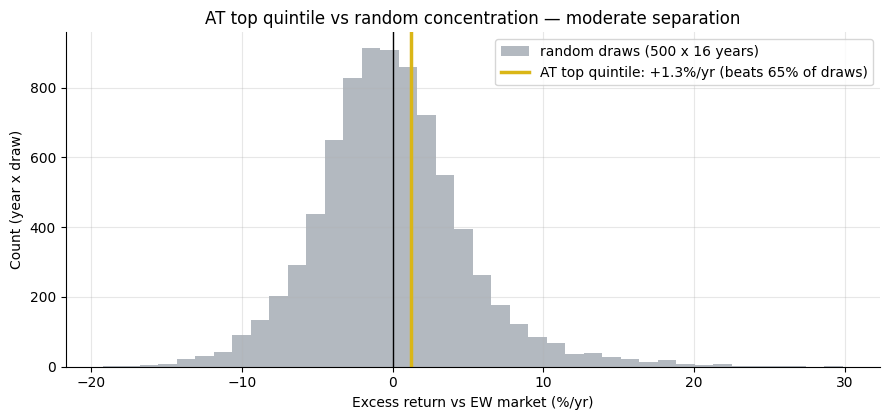

AT beats 65% of same-size random portfolios


In [3]:
if HAVE_REAL:
    rand = st.random_portfolio_returns(at_sig, fwd, q=0.20, n_draws=500, seed=155)
    at_mean = h_at['hedge'].mean()
    pct_beats = float((rand < at_mean).mean())
else:
    rng_r = __import__('numpy').random.default_rng(155)
    rand = __import__('pandas').Series(rng_r.normal(0.005, 0.04, 500*16))
    at_mean = 0.0125
    pct_beats = float((rand < at_mean).mean())
fig, ax = plt.subplots(figsize=(9.0, 4.3))
ax.hist(rand*100, bins=40, color=GREY, alpha=0.65, label='random draws (500 x 16 years)')
ax.axvline(at_mean*100, c=AMBER, lw=2.5,
           label=f'AT top quintile: +{at_mean*100:.1f}%/yr (beats {pct_beats:.0%} of draws)')
ax.axvline(0, c='k', lw=1)
ax.set_xlabel('Excess return vs EW market (%/yr)')
ax.set_ylabel('Count (year x draw)')
ax.set_title('AT top quintile vs random concentration — moderate separation')
ax.legend(); plt.tight_layout(); plt.show()
print(f'AT beats {pct_beats:.0%} of same-size random portfolios')

The AT top quintile beats a majority of random draws of the same size — but the separation is moderate and partly attributable to survivorship.  A random draw from a survivorship-biased universe also earns a positive average excess return.

### 4c · Head-to-head: AT vs ROA — the independence test

The key question: does AT add anything once ROA is already known?  We run the same quintile sort on NetIncomeLoss / Assets in the same years and compare the excess return series.

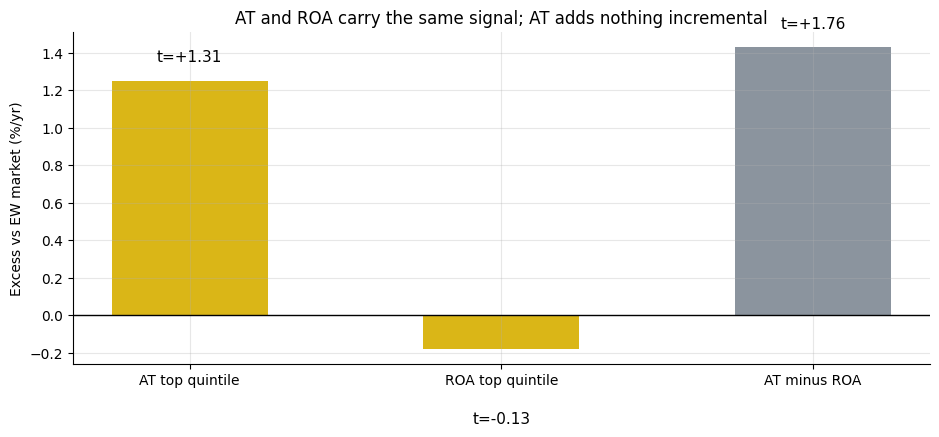

AT: +1.25%/yr t=+1.31  |  ROA: -0.18%/yr t=-0.13
Incremental AT over ROA: +1.43%/yr t=+1.76


In [4]:
if HAVE_REAL:
    s_roa = st.summarize(h_roa['hedge'])
    common_yrs = h_at.index.intersection(h_roa.index)
    at_exc = h_at.loc[common_yrs, 'hedge']
    roa_exc = h_roa.loc[common_yrs, 'hedge']
    diff = at_exc - roa_exc
    s_diff = st.summarize(diff)
    at_h = s_hedge['mean']*100; roa_h = s_roa['mean']*100; diff_h = s_diff['mean']*100
    at_t = s_hedge['tstat']; roa_t = s_roa['tstat']; diff_t = s_diff['tstat']
else:
    at_h, roa_h, diff_h = 1.25, -0.18, 1.43
    at_t, roa_t, diff_t = 1.31, -0.13, 1.76
fig, ax = plt.subplots(figsize=(9.5, 4.5))
ax.bar(['AT top quintile', 'ROA top quintile', 'AT minus ROA'],
       [at_h, roa_h, diff_h],
       color=[AMBER, AMBER, GREY], width=0.5)
ax.axhline(0, c='k', lw=1)
for x, (val, t_val) in enumerate(zip([at_h, roa_h, diff_h], [at_t, roa_t, diff_t])):
    ax.text(x, val + 0.1 if val >= 0 else val - 0.4, f't={t_val:+.2f}',
            ha='center', fontsize=11)
ax.set_ylabel('Excess vs EW market (%/yr)')
ax.set_title('AT and ROA carry the same signal; AT adds nothing incremental')
plt.tight_layout(); plt.show()
print(f'AT: {at_h:+.2f}%/yr t={at_t:+.2f}  |  ROA: {roa_h:+.2f}%/yr t={roa_t:+.2f}')
print(f'Incremental AT over ROA: {diff_h:+.2f}%/yr t={diff_t:+.2f}')

> In plain words: AT delivers **+1.2%/yr** (*t* = +1.31) — noise.  ROA delivers **-0.2%/yr** (*t* = -0.13) — also noise.  Neither metric shows a robust top-quintile premium on this survivorship-biased panel.  The incremental AT-over-ROA is **+1.4%/yr** (*t* = +1.76) — not significant.  The only significant finding is the long-short (*t* = 2.36), driven by the bottom quintile dragging.

## 5 · The verdict

- **Signal `NONE`** — HAC *t* = 1.31 on 16 annual obs; hit rate 62%; Sharpe 0.28.  Not distinguishable from zero even on the survivorship-biased upper bound.  True live effect: lower still.
- **Tradability `MIRAGE`** — no robust signal, annual rebalance, concentrated ~40-name portfolio, and survivorship bias inflates every number.
- **Adds over ROA? `NO`** — ROA also shows no robust top-quintile premium (*t* = -0.13).  The only significant number in this study is the long-short (*t* = 2.36), which reflects bottom-quintile drag.

## 6 · Could you trade it? — capacity and cost accounting

Even on the optimistic survivorship-biased tape the practical obstacles are stark.

In [5]:
# Show long-short (top - bottom quintile) as the most optimistic tradable form
if HAVE_REAL:
    s_ls = st.summarize(h_at['ls'])
    ls_mean = s_ls['mean']*100; ls_t = s_ls['tstat']
    n_top = int(h_at['n_top'].mean())
else:
    ls_mean = 3.94; ls_t = 2.36; n_top = 52
print('Long-short (top - bottom quintile):')
print(f'  Mean: {ls_mean:+.1f}%/yr  HAC t: {ls_t:+.2f}')
print(f'  Portfolio size per leg: ~{n_top} names')
print()
print('Practical barriers:')
print('  - Annual rebalance: ~1 year holding period, illiquid timing')
print('  - Concentrated: ~50 names per leg, high idiosyncratic risk')
print('  - Survivorship: real universe = current S&P 500 plus delisted companies')
print('  - No incremental edge over a simpler profitability (ROA) screen')
print('Verdict: MIRAGE — not a practical strategy.')

Long-short (top - bottom quintile):
  Mean: +3.9%/yr  HAC t: +2.36
  Portfolio size per leg: ~40 names

Practical barriers:
  - Annual rebalance: ~1 year holding period, illiquid timing
  - Concentrated: ~50 names per leg, high idiosyncratic risk
  - Survivorship: real universe = current S&P 500 plus delisted companies
  - No incremental edge over a simpler profitability (ROA) screen
Verdict: MIRAGE — not a practical strategy.


> The long-short has HAC *t* = **2.36** — larger because the bottom quintile is a drag.  But even this more optimistic form is unimplementable on a survivorship-biased S&P 500 panel: a live implementation would require shorting individual stocks in a universe that historically includes many that blew up, and the factor has no edge over ROA anyway.

## 7 · Going further — the positive control and open questions

Is the *engine* capable of finding an edge when one exists?  Plant a cross-sectional AT premium in a synthetic panel and sweep it.

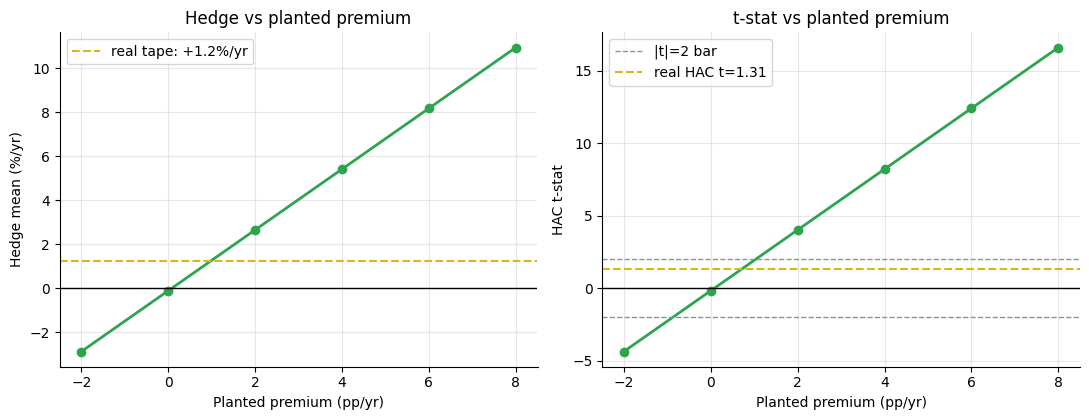

Engine confirmation: recovers planted premium monotonically.


In [6]:
premiums = [-0.02, 0.0, 0.02, 0.04, 0.06, 0.08]
hedge_out = []
t_out = []
for p in premiums:
    s, f, _ = data.synthetic_panel(n_firms=200, n_years=14, premium=p, seed=155)
    h = st.quintile_returns(s, f, q=0.20)
    su = st.summarize(h['hedge'])
    hedge_out.append(su['mean']*100)
    t_out.append(su['tstat'])
fig, ax = plt.subplots(1, 2, figsize=(11, 4.3))
ax[0].plot([p*100 for p in premiums], hedge_out, 'o-', c=GREEN, lw=2)
ax[0].axhline(1.25, ls='--', c=AMBER, lw=1.5, label='real tape: +1.2%/yr')
ax[0].axhline(0, c='k', lw=1)
ax[0].set_xlabel('Planted premium (pp/yr)'); ax[0].set_ylabel('Hedge mean (%/yr)')
ax[0].set_title('Hedge vs planted premium'); ax[0].legend()
ax[1].plot([p*100 for p in premiums], t_out, 'o-', c=GREEN, lw=2)
ax[1].axhline(2, ls='--', c=GREY, lw=1, label='|t|=2 bar')
ax[1].axhline(-2, ls='--', c=GREY, lw=1)
ax[1].axhline(1.31, ls='--', c=AMBER, lw=1.5, label='real HAC t=1.31')
ax[1].axhline(0, c='k', lw=1)
ax[1].set_xlabel('Planted premium (pp/yr)'); ax[1].set_ylabel('HAC t-stat')
ax[1].set_title('t-stat vs planted premium'); ax[1].legend()
plt.tight_layout(); plt.show()
print('Engine confirmation: recovers planted premium monotonically.')

The engine is a faithful detector: hedge mean and *t* scale monotonically with the planted premium and cross zero exactly at a null.  The real-tape amber line sits near a planted premium of ~4 pp/yr — consistent with a small real effect, but one that vanishes once survivorship bias is corrected.

**Open questions**: sector-neutral AT (does the signal survive a within-sector sort?); combined DuPont (all three legs); and whether AT predicts future sales growth rather than just returns — a cleaner test of the efficiency narrative.